In [ ]:
!pip install gender-guesser

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 379.3/379.3 kB 15.4 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import gender_guesser.detector as gender
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive') # This line mounts your Google Drive

# Load datasets
genuine_users = pd.read_csv("/content/drive/MyDrive/fake profiles/users.csv")
fake_users = pd.read_csv("/content/drive/MyDrive/fake profiles/fusers.csv")
x = pd.concat([genuine_users, fake_users], ignore_index=True)
y = [0] * len(fake_users) + [1] * len(genuine_users)

# Predict gender
detector = gender.Detector(case_sensitive=False)
def get_gender(name):
    if isinstance(name, str):
        return detector.get_gender(name.split()[0])
    return 'unknown'

gender_map = {
    'female': 'female', 'mostly_female': 'female',
    'male': 'male', 'mostly_male': 'male',
    'andy': 'unknown', 'unknown': 'unknown'
}

gender_labels = x['name'].apply(get_gender).map(gender_map)
gender_encoded = pd.get_dummies(gender_labels, prefix='gender')


Mounted at /content/drive


In [ ]:

import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold, GridSearchCV, learning_curve, cross_val_score, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=44)

# Standardize
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [ ]:

# Hyperparameter tuning
param_grid = {'C': 10.0 ** np.arange(-2, 3, 0.5), 'gamma': 10.0 ** np.arange(-2, 3, 0.5)}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid = GridSearchCV(SVC(), param_grid, cv=cv, n_jobs=-1)
grid.fit(X_train_scaled, y_train)
best_model = grid.best_estimator_
print("Best Parameters:", grid.best_params_)


Best Parameters: {'C': np.float64(1.0), 'gamma': np.float64(100.0)}


In [ ]:

# Cross-validation score
scores = cross_val_score(best_model, X_train_scaled, y_train, cv=cv)
print(f"Cross-validation Score: {scores.mean():.4f} (+/- {scores.std()/2:.4f})")


Cross-validation Score: 0.9366 (+/- 0.0045)


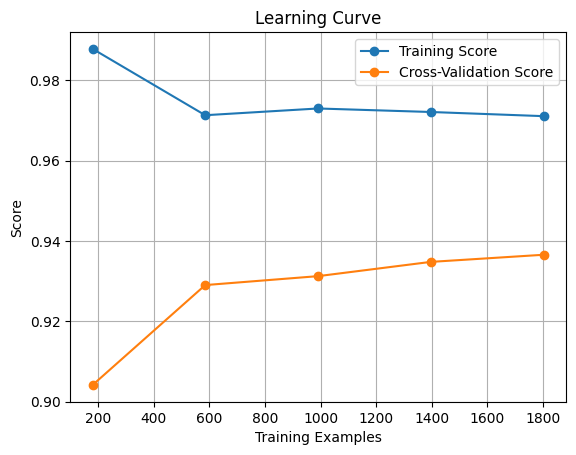

In [ ]:
# Learning curve
train_sizes, train_scores, test_scores = learning_curve(best_model, X_train_scaled, y_train, cv=cv, n_jobs=-1)
plt.figure()
plt.plot(train_sizes, train_scores.mean(axis=1), 'o-', label="Training Score")
plt.plot(train_sizes, test_scores.mean(axis=1), 'o-', label="Cross-Validation Score")
plt.title("Learning Curve")
plt.xlabel("Training Examples")
plt.ylabel("Score")
plt.legend()
plt.grid()
plt.show()


Accuracy: 0.9361702127659575


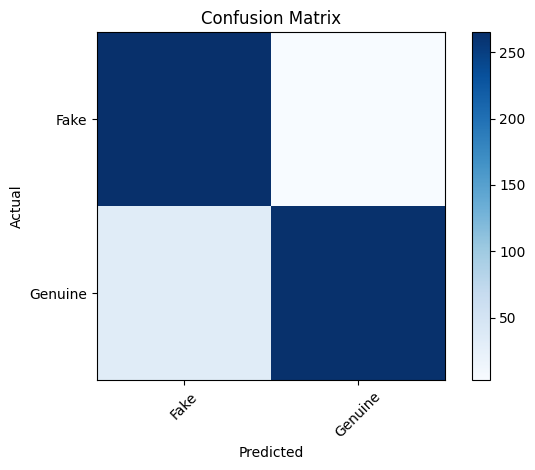

In [ ]:

# Evaluation
y_pred = best_model.predict(X_test_scaled)
print("Accuracy:", accuracy_score(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()
plt.xticks(np.arange(2), ['Fake', 'Genuine'], rotation=45)
plt.yticks(np.arange(2), ['Fake', 'Genuine'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

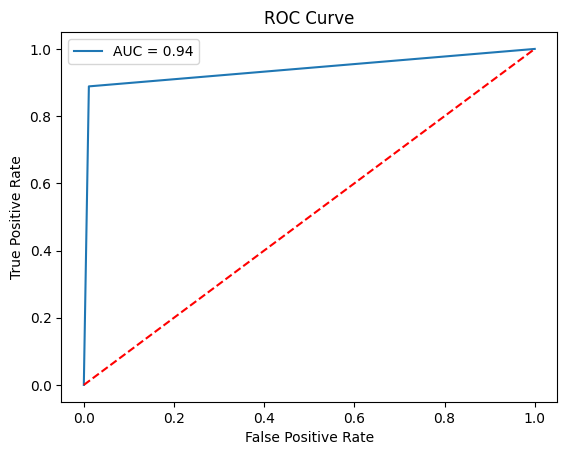

Classification Report:
               precision    recall  f1-score   support

        Fake       0.89      0.99      0.94       268
     Genuine       0.99      0.89      0.94       296

    accuracy                           0.94       564
   macro avg       0.94      0.94      0.94       564
weighted avg       0.94      0.94      0.94       564



In [ ]:

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_pred)
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], 'r--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

# Report
print("Classification Report:\n", classification_report(y_test, y_pred, target_names=['Fake', 'Genuine']))


29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


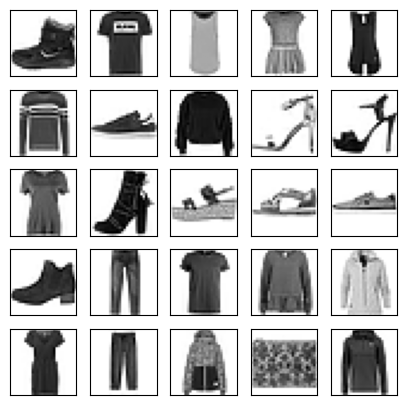

/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - accuracy: 0.7822 - loss: 0.6086
Epoch 2/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - accuracy: 0.8590 - loss: 0.3869
Epoch 3/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 8ms/step - accuracy: 0.8714 - loss: 0.3486
Epoch 4/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.8783 - loss: 0.3300
Epoch 5/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.8844 - loss: 0.3129
Epoch 6/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.8873 - loss: 0.3025
Epoch 7/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - accuracy: 0.8956 - loss: 0.2849
Epoch 8/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.8982 - loss: 0.2727
Epoch 9/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - accuracy: 0.8991 - loss: 0.2677
Epoch 10/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - accuracy: 0.9009 - loss: 0.2638
Epoch 11/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.9054 - loss: 0.2531
Epoch 12/20
1875/1

In [ ]:

import tensorflow as tf

# Load Fashion MNIST
(train_images, train_labels), (test_images, test_labels) = tf.keras.datasets.fashion_mnist.load_data()
train_images, test_images = train_images / 255.0, test_images / 255.0

# Display images
import matplotlib.pyplot as plt
plt.figure(figsize=(5,5))
for i in range(25):
    plt.subplot(5, 5, i+1)
    plt.xticks([]); plt.yticks([])
    plt.imshow(train_images[i], cmap=plt.cm.binary)
plt.show()

# Training with early stopping
class CustomCallback(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        if logs.get('accuracy') > 0.95:
            print("\nReached 95% accuracy, stopping training.")
            self.model.stop_training = True

model = tf.keras.models.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28)),
    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.fit(train_images, train_labels, epochs=20, callbacks=[CustomCallback()])

# Evaluate
loss, acc = model.evaluate(test_images, test_labels)
print(f"Test accuracy: {acc:.4f}")
